In [1]:
import sys
sys.path.append('..')

import importlib

from util import config
from util.data_loader import DataLoader
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)

import numpy as np
import pandas as pd
from tqdm import tqdm

def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti` (trigger index), and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

import numpy as np
import pandas as pd

def add_distance_travelled(position):
    """
    Adds per-step distance and cumulative distance to a position dataframe.

    Requires columns: ['t','x','y'].
    Returns a COPY with new columns:
      - dx, dy
      - step_dist: distance between consecutive samples
      - cum_dist: cumulative distance from start
    """
    if position is None or len(position) == 0:
        return None

    pos = position.copy()

    # differences between consecutive samples
    dx = np.diff(pos['x'].values, prepend=pos['x'].values[0])
    dy = np.diff(pos['y'].values, prepend=pos['y'].values[0])

    pos['dx'] = dx
    pos['dy'] = dy

    # step distance (same units as x,y)
    pos['step_dist'] = np.sqrt(dx**2 + dy**2)

    # cumulative distance
    pos['cum_dist'] = np.cumsum(pos['step_dist'])

    return pos


def add_speed(position):
    """
    Adds instantaneous speed to the position DataFrame.
    Assumes:
      - x, y in cm
      - t in ms
    Speed returned in cm/s
    """
    pos = position.copy()

    dx = np.diff(pos['x'].values)
    dy = np.diff(pos['y'].values)
    dt = np.diff(pos['t'].values) / 1000.0  # ms → s

    dist = np.sqrt(dx**2 + dy**2)

    speed = np.zeros(len(pos))
    valid = dt > 0
    speed[1:][valid] = dist[valid] / dt[valid]

    pos['speed'] = speed
    return pos

# colour coding
def get_genotype_color(genotype=None):
    # Create a dictionary to match the animal genotype with the colour.
    genotype_color = {}
    genotype_color['ChR2'] = '#F44636ff'
    genotype_color['eYFP_ChR2'] =  '#5ba0d8ff'
    genotype_color['ChR2_short'] = '#FFA623ff'
    genotype_color['CA1'] = '#63D15Aff'
    genotype_color['CA3'] = '#7b62c5ff'
    genotype_color['NAc'] = '#FF9BD6ff'
    genotype_color['ArchT'] = "#22d2bdff"
    genotype_color['eYFP_ArchT'] = '#5ba0d8ff'
    genotype_color['CA1_control'] = '#5ba0d8ff'
    genotype_color['NAc_control'] = '#5ba0d8ff'
    genotype_color['WT'] = 'grey'
    if genotype == None:
        return genotype_color
    else:
        return genotype_color[genotype]
# other good colours i could use
'#00877D'
'#A4B2FF'
'#FF9BD6'
'#A66A5C'
"#7b62c5ff"
'#1F2A63'
'#C276A5'
"#38D28A"

# significance test
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."


In [2]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[45])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

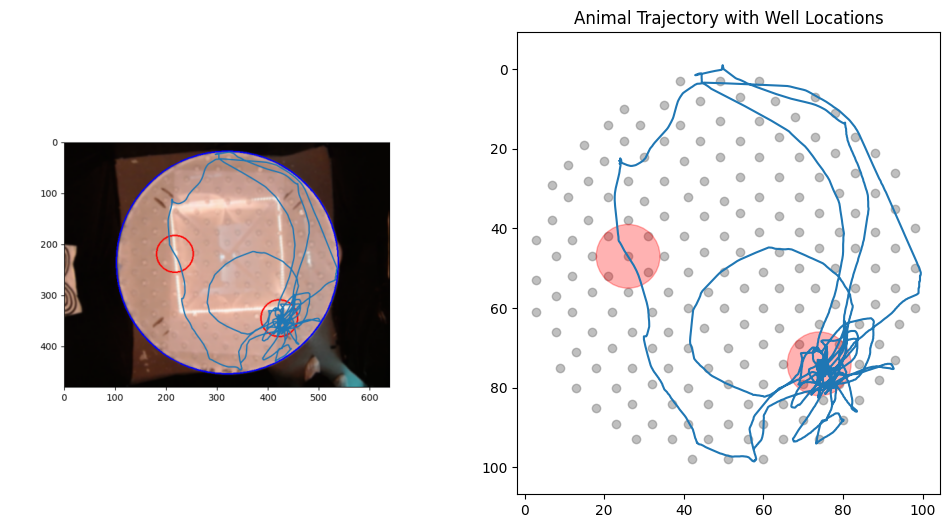

In [3]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))

axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)
# Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')

In [4]:
triggerLoc

,well_row,well_col,x,y
0,J,3,26,47
1,Q,8,74,74


In [5]:
position_ = add_dist_to_trigger(position, triggerLoc)
trigger_num = len(triggerLoc)
dfs = []
for i in range(trigger_num):
    df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
    df_trigger_interaction["trigger_id"] = i + 1
    dfs.append(df_trigger_interaction)
df_all_triggers = pd.concat(dfs, ignore_index=True)
df_all_triggers

,t_enter,t_exit,duration,trigger_id
0,160470,161746,1276,1
1,2017,7183,5166,2
2,8962,14420,5458,2
3,18488,23541,5053,2
4,23672,25425,1753,2
5,28682,31495,2813,2
6,33670,60280,26610,2
7,63489,80872,17383,2
8,82751,86006,3255,2
9,87337,89477,2140,2


In [6]:
metadata

,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,genotype,test_order,remapping,short_duration,LFP,animal_note
0,1,A,20241205,1,1,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
1,1,A,20241205,1,2,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
2,1,A,20241205,1,3,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
3,1,A,20241205,1,4,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
4,1,A,20241205,1,5,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6755,89,N10,20260424,8,6,L,5,NaN,1,NaN,NAc_control,NaN,0,0,0,NaN
6756,89,N10,20260424,8,7,L,5,NaN,1,NaN,NAc_control,NaN,0,0,0,NaN
6757,89,N10,20260424,8,8,L,5,NaN,1,NaN,NAc_control,NaN,0,0,0,NaN
6758,89,N10,20260425,9,1,T,1,NaN,0,NaN,NAc_control,NaN,0,0,0,NaN


In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# New column: number of crossings into ANY trigger zone
metadata['n_crossings'] = np.nan

R_TRIGGER = (10/1.2)  # radius defining trigger zone

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    
    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'n_crossings'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    # Build visit episodes for each trigger
    dfs = []
    for i in range(len(triggerLoc)):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        if len(df_trigger_interaction) == 0:
            continue
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    # Number of crossings = number of visits to any trigger
    if len(dfs) == 0:
        n_crossings = 0
    else:
        df_all_triggers = pd.concat(dfs, ignore_index=True)
        # (sorting not required for counting, but harmless)
        # df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)
        n_crossings = len(df_all_triggers)

    metadata.at[trial_id, 'n_crossings'] = n_crossings

 11%|█▏        | 704/6195 [00:07<00:53, 103.56it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 19%|█▉        | 1179/6195 [00:12<00:47, 104.68it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 42%|████▏     | 2608/6195 [00:26<00:22, 160.02it/s]

...

 82%|████████▏ | 5049/6195 [00:47<00:11, 102.05it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-071_id-C1/ses-01_date-20260326/behav/sub-071_ses-01_trial-06_data-position.csv' does not exist.


 87%|████████▋ | 5419/6195 [00:51<00:07, 101.83it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


100%|██████████| 6195/6195 [00:58<00:00, 105.28it/s]


In [ ]:
# number of crossings. Restrict to ChR2 learning trials
metadata_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['genotype'] == 'ChR2') &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].reset_index(drop=True)

performance_mat = []

plt.figure()

for sub in metadata_L['sub'].unique():
    meta_sub = metadata_L[metadata_L['sub'] == sub]

    # Mean number of crossings per day for this animal
    mean_crossings_by_day = meta_sub.groupby('trial_type_day')['n_crossings'].mean()
    mean_crossings_by_day = mean_crossings_by_day.sort_index()

    # Expect 5 days; skip animals missing days
    if len(mean_crossings_by_day) != 5:
        continue

    performance_mat.append(mean_crossings_by_day.values)

    # Individual animal trace (thin black)
    plt.plot(range(5), mean_crossings_by_day.values, '-o', color='k', alpha=0.3)

# Group mean ± SEM across animals
if len(performance_mat) > 0:
    performance_mat = np.vstack(performance_mat)
    mean_performance = np.nanmean(performance_mat, axis=0)
    sem_performance = np.nanstd(performance_mat, axis=0) / np.sqrt(performance_mat.shape[0])

    plt.errorbar(
        range(5),
        mean_performance,
        yerr=sem_performance,
        fmt='-o',
        color='r',
        capsize=5
    )

plt.xlabel('Learning Day')
plt.ylabel('Mean number of reward zone crossings per trial')
plt.title('Average Number of Reward Zone Crossings over Learning Days (ChR2, L trials)')
plt.xticks(range(5), labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'])
plt.tight_layout()
plt.show()

ChR2 long animals plotted: 12
eYFP animals plotted: 5
ChR2 short animals plotted: 0


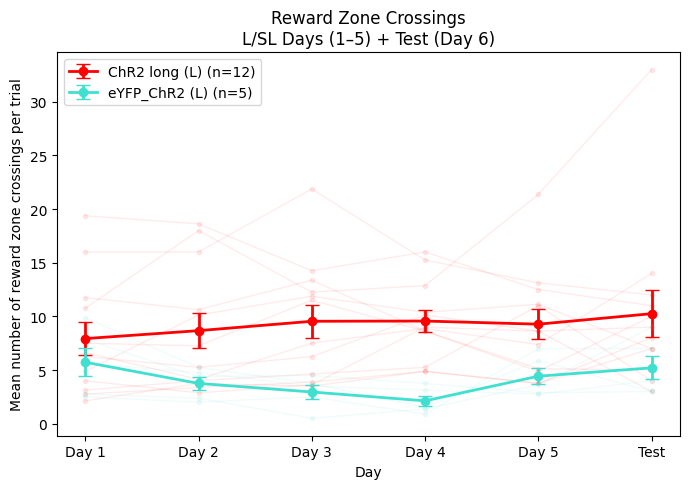

In [8]:
# number of crossings, ChR2 & eYFP_ChR2 & Short duration

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, relevant genotypes & trial types
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL', 'T']))
].copy()

plot_days = np.arange(1, 7)  # 1–5 learning + day 6 = first test


# ------------------------------------------------------------
# 1. Helper: build subject × day matrix for n_crossings
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L',
                       short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) matrix of n_crossings
      - subjects: list of subject IDs

    learning_type: 'L' or 'SL'
    short_duration_val:
        None  -> ignore this column
        0 or 1 -> restrict to it
    """

    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()
        ms['plot_day'] = np.nan

        # Learning trials for this animal (L or SL)
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # Learning days = trial_type_day
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # first T session after last learning session
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean crossings per day
        mean_by_day = ms.groupby('plot_day')['n_crossings'].mean()

        # build vector [days 1–6]
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for 3 groups
# ------------------------------------------------------------

# Group 1: ChR2 long → L learning
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2 → L learning
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: ChR2 short → SL learning
mat_ChR2_short, subs_ChR2_short = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='SL',
    short_duration_val=1,
    require_complete=True
)

print("ChR2 long animals plotted:", len(subs_ChR2_long))
print("eYFP animals plotted:", len(subs_eYFP))
print("ChR2 short animals plotted:", len(subs_ChR2_short))


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # convert to 0–5 indexing

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return

    # faded single-animal lines
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-o',
            color=color,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o',
        color=color,
        linewidth=2,
        markersize=6,
        capsize=5,
        label=f'{label} (n={len(subs)})'
    )


# Plot the 3 groups
plot_group(mat_ChR2_long, subs_ChR2_long, color='red',       label='ChR2 long (L)')
plot_group(mat_eYFP,      subs_eYFP,      color='turquoise', label='eYFP_ChR2 (L)')
plot_group(mat_ChR2_short, subs_ChR2_short, color='#f77f00', label='ChR2 short (SL)')


plt.xlabel('Day')
plt.ylabel('Mean number of reward zone crossings per trial')
plt.title('Reward Zone Crossings\nL/SL Days (1–5) + Test (Day 6)')
plt.xticks(
    ticks=np.arange(6),
    labels=['Day 1','Day 2','Day 3','Day 4','Day 5','Test']
)
plt.legend()
plt.tight_layout()
plt.show()

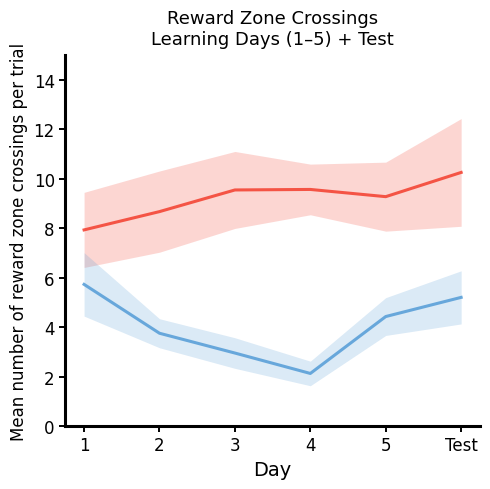

In [9]:
# ------------------------------------------------------------
# 3. Plot: mean ± shaded SEM, no individual traces
# ------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # convert to 0–5 indexing

def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:          (n_animals x n_days) matrix of n_crossings
    subs:         list of animal IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2', 'eYFP_ChR2', 'ChR2_short')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no individual traces)
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )

# --- plot all 3 groups using colour function ---
plot_group_shaded(
    mat_ChR2_long,
    subs_ChR2_long,
    genotype_key='ChR2',
    label='ChR2_long'
)

plot_group_shaded(
    mat_eYFP,
    subs_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2'
)

plot_group_shaded(
    mat_ChR2_short,
    subs_ChR2_short,
    genotype_key='ChR2_short',
    label='ChR2_short'
)

# ------------------------------------------------------------
# Axes, labels, and style
# ------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Mean number of reward zone crossings per trial', fontsize=12)
plt.title('Reward Zone Crossings\nLearning Days (1–5) + Test', fontsize=13, pad=8)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

#plt.legend(frameon=False)
plt.ylim(0,15)
plt.tight_layout()
plt.show()

Animals included:
  VTA (ChR2):
    animals plotted: 12
    ids plotted:     ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  NAc (NAc):
    animals plotted: 7
    ids plotted:     ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  NAc control (NAc_control):
    animals plotted: 3
    ids plotted:     ['N8', 'N9', 'N10']


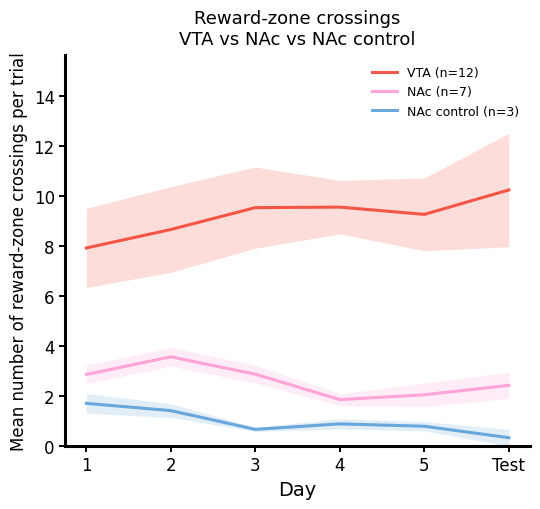

In [12]:
# ============================================================
# Number of reward-zone crossings across L1-L5 + Test
# Flexible groups
# ============================================================
# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
# GROUPS = ['ChR2', 'eYFP_ChR2', 'ChR2_short']
# GROUPS = ['CA1', 'CA1_control', 'CA3', 'CA3_control']
GROUPS = ['ChR2', 'NAc', 'NAc_control']
# GROUPS = ['ChR2', 'CA1', 'CA3', 'CA1_control']

EXCLUDE_ID = ['AS', 'AN']        # e.g. ['AS']
EXCLUDE_SUBS = []      # e.g. [43]

REQUIRE_COMPLETE = False
PLOT_INDIVIDUAL = False
PLOT_SEM_BARS = False

VALUE_COL = 'n_crossings'

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
}

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ------------------------------------------------------------
# 1. Base metadata filter
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(GROUPS)) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[VALUE_COL].notna())
].copy()

if len(EXCLUDE_ID) > 0:
    meta_all = meta_all[
        ~meta_all['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_all = meta_all[
        ~meta_all['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2. Build subject × day matrix for each group
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, value_col):
    """
    Returns:
      - perf_mat: animal x day matrix
      - subjects: subject IDs
      - animal_ids: animal letter IDs

    Uses L learning trials for all groups.
    No short_duration filtering.
    """

    meta_g = meta_all[
        (meta_all['genotype'] == genotype) &
        (meta_all['trial_type'].isin(['L', 'T']))
    ].copy()

    if len(meta_g) == 0:
        return None, [], []

    perf_mat = []
    subjects = []
    animal_ids = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()
        ms['plot_day'] = np.nan

        # learning days 1–5
        mL = ms[
            (ms['trial_type'] == 'L') &
            (ms['trial_type_day'].isin([1, 2, 3, 4, 5]))
        ].copy()

        if len(mL) == 0:
            continue

        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # first T session after last learning session
        last_L_ses = mL['ses'].max()

        mT_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_L_ses)
        ]

        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()

        idx_T = ms.index[
            (ms['trial_type'] == 'T') &
            (ms['ses'] == first_T_ses)
        ]

        ms.loc[idx_T, 'plot_day'] = 6

        ms = ms[ms['plot_day'].isin(plot_days)].copy()

        mean_by_day = ms.groupby('plot_day')[value_col].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_ids.append(str(ms['id'].dropna().iloc[0]))
        else:
            animal_ids.append(str(sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids


group_data = {}

print("Animals included:")
for g in GROUPS:
    mat_g, subs_g, ids_g = build_group_matrix(meta_all, g, VALUE_COL)

    group_data[g] = {
        'mat': mat_g,
        'subs': subs_g,
        'ids': ids_g,
    }

    print(f"  {DISPLAY_NAME.get(g, g)} ({g}):")
    print(f"    animals plotted: {len(subs_g)}")
    print(f"    ids plotted:     {ids_g}")

# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.5, 5.2))

def plot_group_shaded(ax, mat, subs, genotype_key, label,
                      alpha_fill=0.18,
                      alpha_line=0.9,
                      alpha_individual=0.12):
    if mat is None or len(subs) == 0:
        return

    col = get_genotype_color(genotype_key)

    if PLOT_INDIVIDUAL:
        for row in mat:
            ax.plot(
                x_vals,
                row,
                '-',
                color=col,
                alpha=alpha_individual,
                linewidth=1.0,
                label='_nolegend_',
                zorder=1
            )

    mean_ = np.nanmean(mat, axis=0)

    n_per_day = np.sum(~np.isnan(mat), axis=0)
    sem_ = np.nanstd(mat, axis=0, ddof=1) / np.sqrt(n_per_day)
    sem_[n_per_day <= 1] = 0

    ax.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0,
        zorder=2
    )

    ax.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})',
        zorder=3
    )

    if PLOT_SEM_BARS:
        ax.errorbar(
            x_vals,
            mean_,
            yerr=sem_,
            fmt='none',
            ecolor=col,
            elinewidth=1.2,
            capsize=3,
            alpha=0.9,
            zorder=4
        )


for g in GROUPS:
    plot_group_shaded(
        ax,
        group_data[g]['mat'],
        group_data[g]['subs'],
        genotype_key=g,
        label=DISPLAY_NAME.get(g, g)
    )

# ------------------------------------------------------------
# 4. Axes + style
# ------------------------------------------------------------
ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel('Mean number of reward-zone crossings per trial', fontsize=12)

ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

display_groups = ' vs '.join([DISPLAY_NAME.get(g, g) for g in GROUPS])

ax.set_title(
    f'Reward-zone crossings\n{display_groups}',
    fontsize=13,
    pad=8
)

ax.legend(frameon=False, fontsize=9)

# auto y-limit based on mean + SEM
ymax_candidates = []
for g in GROUPS:
    mat = group_data[g]['mat']
    if mat is None:
        continue

    mean_ = np.nanmean(mat, axis=0)
    n_per_day = np.sum(~np.isnan(mat), axis=0)
    sem_ = np.nanstd(mat, axis=0, ddof=1) / np.sqrt(n_per_day)
    sem_[n_per_day <= 1] = 0
    ymax_candidates.append(np.nanmax(mean_ + sem_))

if len(ymax_candidates) > 0:
    ymax = np.nanmax(ymax_candidates)
    ax.set_ylim(0, ymax * 1.25)

plt.tight_layout()
plt.show()

In [ ]:
# number of crossings, F231a VS WT

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, relevant genotypes & trial types
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
         ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L','T'])) &
    (metadata['id'] != 'BQ')
].copy()

plot_days = np.arange(1, 7)  # 1–5 learning + day 6 = first test


# ------------------------------------------------------------
# 1. Helper: build subject × day matrix for n_crossings
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L',
                       short_duration_val=None, require_complete=True):

    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))


    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()
        ms['plot_day'] = np.nan

        # Learning trials for this animal (L or SL)
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # Learning days = trial_type_day
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # first T session after last learning session
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean crossings per day
        mean_by_day = ms.groupby('plot_day')['n_crossings'].mean()

        # build vector [days 1–6]
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for 3 groups
# ------------------------------------------------------------

# Group 1: ChR2 long → L learning
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='F231A',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2 → L learning
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='F231A_wt',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # convert to 0–5 indexing

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return

    # faded single-animal lines
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-o',
            color=color,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o',
        color=color,
        linewidth=2,
        markersize=6,
        capsize=5,
        label=f'{label} (n={len(subs)})'
    )


# Plot the 3 groups
plot_group(mat_ChR2_long, subs_ChR2_long, color='red',       label='F231A')
plot_group(mat_eYFP,      subs_eYFP,      color='turquoise', label='F231A_wt')


plt.xlabel('Day')
plt.ylabel('Mean number of reward zone crossings per trial')
plt.title('Reward Zone Crossings')
plt.xticks(
    ticks=np.arange(6),
    labels=['1','2','3','4','5','Test']
)
plt.legend()
plt.tight_layout()
plt.show()

Animals included (n):
  ChR2 long : 12
  eYFP      : 5


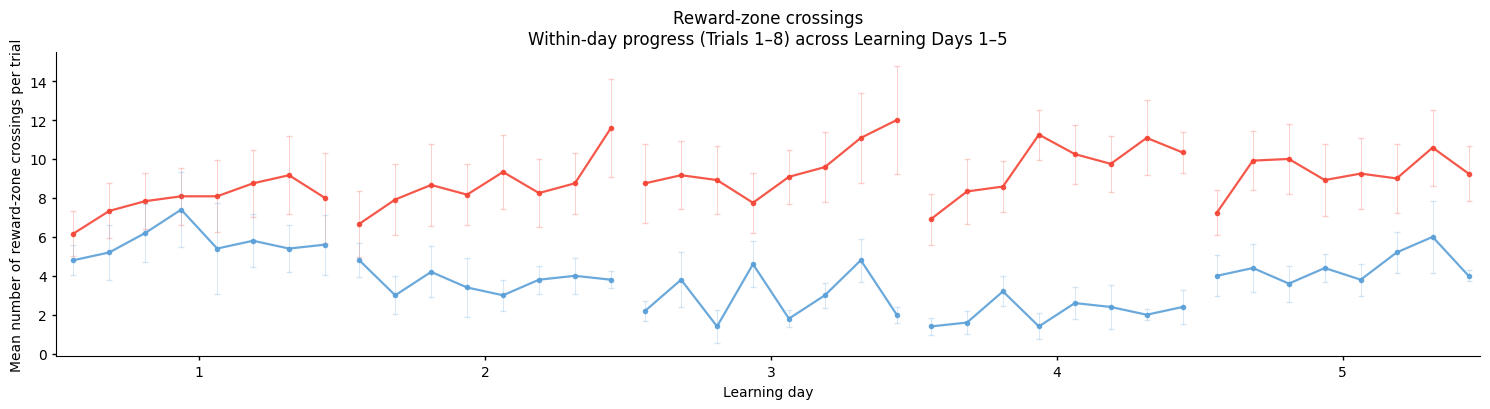

In [10]:
# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: n_crossings (per trial)
# Groups are easy to toggle by commenting out blocks below.
# ============================================================

# ------------------------------------------------------------
# 1) Base filter (edit these lines to switch cohorts)
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &   # optional global exclusion
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    # (metadata['genotype'].isin(['F231A', 'F231A_wt'])) & ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L'])) &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['n_crossings'].notna())        # <-- crossings metric
].copy()

days   = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) subject × trial matrix for a given day (allow missing trials)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['n_crossings'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)
        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: mean + faded SEM only (no individual traces)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # mean curve
        ax.plot(
            x, mean_,
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            markersize=3
        )

        # faded SEM bars
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=min(alpha, 0.25),
            elinewidth=0.7,
            capsize=2
        )

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Define groups (COMMENT OUT whichever you don't want)
# ------------------------------------------------------------

# --- Group 1: ChR2 long (L, short_duration=0) ---
meta_ChR2_long = meta_L[
    (meta_L['genotype'] == 'ChR2') &
    # (meta_L['genotype'] == 'F231A') &
    (meta_L['trial_type'] == 'L') &
    (meta_L['short_duration'] == 0)
].copy()

# --- Group 2: ChR2 short (SL, short_duration=1) ---
# meta_ChR2_short = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'SL') &
#     (meta_L['short_duration'] == 1)
# ].copy()

# --- Group 3: eYFP_ChR2 controls (L, any short_duration) ---
meta_eYFP = meta_L[
    (meta_L['genotype'] == 'eYFP_ChR2') &
    # (meta_L['genotype'] == 'F231A_wt') &
    (meta_L['trial_type'] == 'L')
].copy()

# --- Optional extra group example: Hp (if you enable Hp above) ---
# meta_Hp = meta_L[
#      (meta_L['genotype'] == 'Hp') &
#      (meta_L['trial_type'] == 'L')
#  ].copy()

print("Animals included (n):")
print("  ChR2 long :", meta_ChR2_long['sub'].nunique())
# print("  ChR2 short:", meta_ChR2_short['sub'].nunique())
print("  eYFP      :", meta_eYFP['sub'].nunique())
# print("  Hp        :", meta_Hp['sub'].nunique())

# ------------------------------------------------------------
# 7) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

plot_within_day_curves(
    ax,
    meta_ChR2_long,
    color=get_genotype_color('ChR2'),
    alpha=0.9
)

# plot_within_day_curves(
#     ax,
#     meta_ChR2_short,
#     color=get_genotype_color('ChR2_short'),
#     alpha=1.0
# )

plot_within_day_curves(
    ax,
    meta_eYFP,
    color=get_genotype_color('eYFP_ChR2'),
    alpha=0.9
)

# plot_within_day_curves(
#     ax,
#     meta_Hp,
#     color=get_genotype_color('Hp'),
#     alpha=0.9
# )

ax.set_xlabel('Learning day')
ax.set_ylabel('Mean number of reward-zone crossings per trial')

# day labels centered under each day's curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# reduce whitespace + ensure day 5 curve fully visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Reward-zone crossings\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)
plt.tight_layout()
plt.show()

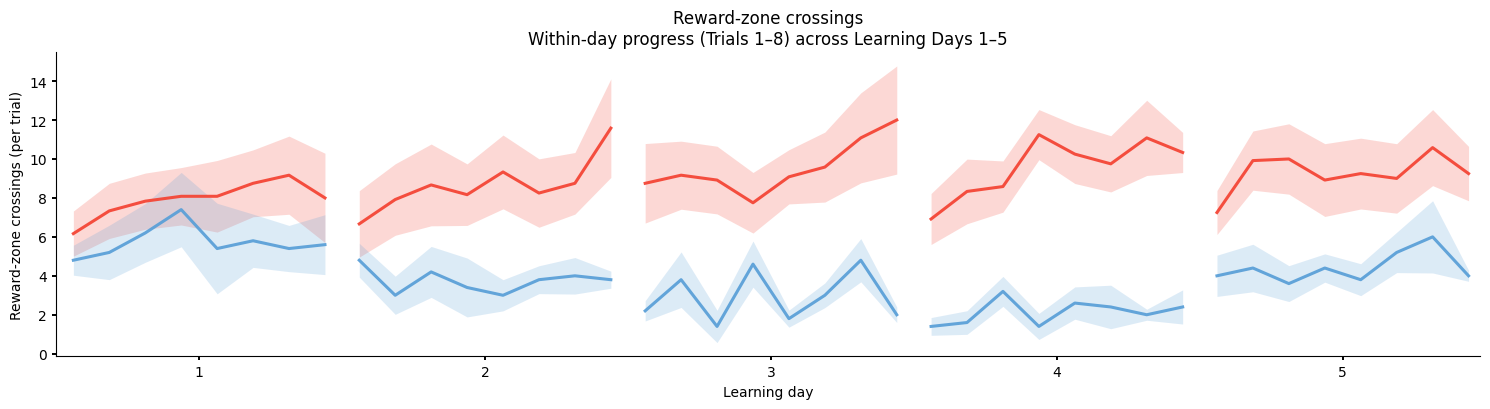

In [11]:
# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: n_crossings (per trial)
# Groups toggle by commenting lines below.
# Style: shaded SEM, no individual traces, no markers.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Base filter (matches your original logic)
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    # (metadata['genotype'].isin(['F231A', 'F231A_wt'])) & ~(metadata['id'].isin(['BQ','BP'])) &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].isin([1,2,3,4,5])) &
    (metadata['n_crossings'].notna())
].copy()

days   = np.array([1,2,3,4,5])
trials = np.arange(1,9)

# ------------------------------------------------------------
# 2) trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day','trial_num','trial_number','trial','trial_idx',
    'trial_index','trial_in_session','trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    meta_L = meta_L.sort_values(['sub','ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub','ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1,8)].copy()

# ------------------------------------------------------------
# 3) Build subject × trial_matrix for each day
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['n_crossings'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)
        if not np.all(np.isnan(vals)):
            rows.append(vals)
    return None if len(rows)==0 else np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper — shaded SEM, no individuals, no markers
# ------------------------------------------------------------
def plot_shaded(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 bins within day

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets
        mean_ = np.nanmean(mat, axis=0)
        n = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n,1))

        # shaded SEM
        ax.fill_between(
            x,
            mean_ - sem_,
            mean_ + sem_,
            color=color,
            alpha=min(alpha*0.22, 0.35),
            linewidth=0
        )

        # mean line
        ax.plot(
            x,
            mean_,
            '-',
            color=color,
            alpha=alpha,
            linewidth=2.2
        )

# ------------------------------------------------------------
# 5) Nature-style frame
# ------------------------------------------------------------
def style_nature(ax):
    for s in ['top','right']:
        ax.spines[s].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1.4)

# ------------------------------------------------------------
# 6) Groups (unchanged toggle logic)
# ------------------------------------------------------------

meta_ChR2_long = meta_L[
    (meta_L['genotype']=='ChR2') &
    (meta_L['trial_type']=='L') &
    (meta_L['short_duration']==0)
].copy()

# meta_ChR2_short = meta_L[
#     (meta_L['genotype']=='ChR2') &
#     (meta_L['trial_type']=='SL') &
#     (meta_L['short_duration']==1)
# ].copy()

meta_eYFP = meta_L[
    (meta_L['genotype']=='eYFP_ChR2') &
    (meta_L['trial_type']=='L')
].copy()

# meta_Hp = meta_L[
#     (meta_L['genotype']=='Hp') &
#     (meta_L['trial_type']=='L')
# ].copy()

# ------------------------------------------------------------
# 7) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1,1, figsize=(15,4.2))

plot_shaded(ax, meta_ChR2_long, color=get_genotype_color('ChR2'), alpha=0.95)
# plot_shaded(ax, meta_ChR2_short, color=get_genotype_color('ChR2_short'), alpha=1.0)
plot_shaded(ax, meta_eYFP,      color=get_genotype_color('eYFP_ChR2'), alpha=0.95)
# plot_shaded(ax, meta_Hp,       color=get_genotype_color('Hp'), alpha=0.95)

ax.set_xlabel('Learning day')
ax.set_ylabel('Reward-zone crossings (per trial)')

ax.set_xticks(days + 0.5)
ax.set_xticklabels(days.astype(str))
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Reward-zone crossings\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)
plt.tight_layout()
plt.show()

ArchT animals plotted:       6
eYFP_ArchT animals plotted: 6


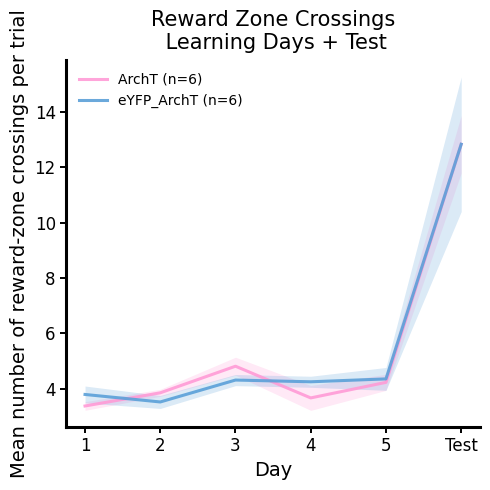

In [15]:
# number of crossings, ArchT & eYFP_ArchT

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, ArchT / eYFP_ArchT, L/T
# ------------------------------------------------------------
meta_LT_Arch = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ArchT', 'eYFP_ArchT'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

plot_days = np.arange(1, 7)  # 1–5 learning + 6 = first test


# ------------------------------------------------------------
# 1. Helper: build subject × day matrix for n_crossings
# ------------------------------------------------------------
def build_group_matrix_arch(meta_df, genotype, short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) n_crossings per day
      - subjects: list of subject IDs

    Learning trials are 'L', test is first 'T' session after last L session.
    short_duration_val:
        None -> no filter
        0 or 1 -> restrict to that value
    """

    mask = (meta_df['genotype'] == genotype) & \
           (meta_df['trial_type'].isin(['L', 'T']))

    if short_duration_val is not None:
        mask &= (meta_df['short_duration'] == short_duration_val)

    meta_g = meta_df[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()
        ms['plot_day'] = np.nan

        # Learning trials (L) for this animal
        mL = ms[ms['trial_type'] == 'L']
        if len(mL) == 0:
            continue

        # assign L days 1–5 from trial_type_day
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # first T session after last L session
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean crossings per plot_day
        mean_by_day = ms.groupby('plot_day')['n_crossings'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for ArchT and eYFP_ArchT
# ------------------------------------------------------------
mat_ArchT,      subs_ArchT      = build_group_matrix_arch(meta_LT_Arch, 'ArchT',
                                                          short_duration_val=None,
                                                          require_complete=True)
mat_eYFP_ArchT, subs_eYFP_ArchT = build_group_matrix_arch(meta_LT_Arch, 'eYFP_ArchT',
                                                          short_duration_val=None,
                                                          require_complete=True)

print("ArchT animals plotted:      ", len(subs_ArchT))
print("eYFP_ArchT animals plotted:", len(subs_eYFP_ArchT))


# ------------------------------------------------------------
# 3. Plot: mean ± shaded SEM, no individual traces
# ------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5

def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:          (n_animals x n_days) matrix of n_crossings
    subs:         list of animal IDs
    genotype_key: key for get_genotype_color (e.g. 'ArchT', 'eYFP_ArchT')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )


# --- plot both groups with your colour function ---
plot_group_shaded(mat_ArchT,      subs_ArchT,
                  genotype_key='ArchT',
                  label='ArchT')

plot_group_shaded(mat_eYFP_ArchT, subs_eYFP_ArchT,
                  genotype_key='eYFP_ArchT',
                  label='eYFP_ArchT')


# ------------------------------------------------------------
# Axes, labels, style
# ------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Mean number of reward-zone crossings per trial', fontsize=14)
plt.title('Reward Zone Crossings\n Learning Days + Test',
          fontsize=15, pad=8)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

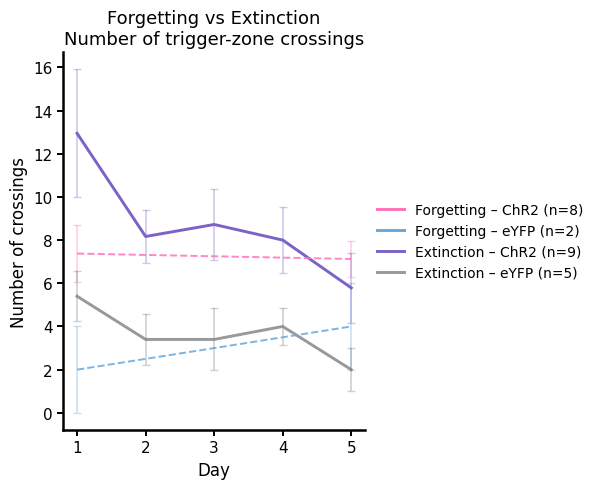

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ----- 1. Restrict to TEST trials, desired genotypes, NOT short_duration -----
meta_T = metadata[
    (metadata['trial_type'] == 'T') &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['short_duration'] != 1) &
    (metadata['n_crossings'].notna())
].copy()

max_day = 5
day_values = np.arange(1, max_day + 1)

# ----- 2. Build subject × test-day matrix (n_crossings) -----
def build_subject_matrix(meta_group):
    """
    For each subject, compute mean number of crossings per test day (1..5)
    and return an array of shape (n_subjects, max_day).
    """
    performance_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        m = meta_group[meta_group['sub'] == sub]

        # average per day for this subject
        mean_d = m.groupby('trial_type_day')['n_crossings'].mean()

        vec = np.full(max_day, np.nan)
        for i, d in enumerate(day_values):
            if d in mean_d.index:
                vec[i] = mean_d.loc[d]

        # skip animals with no data at all
        if np.isnan(vec).all():
            continue

        performance_mat.append(vec)
        subjects.append(sub)

    if len(performance_mat) == 0:
        return None, []

    return np.vstack(performance_mat), subjects


def mean_and_sem(mat):
    """
    Robust mean/SEM:
    - returns NaN for days where all animals are NaN
    """
    if mat is None or mat.size == 0:
        return None, None

    n_days = mat.shape[1]
    mean = np.full(n_days, np.nan)
    sem  = np.full(n_days, np.nan)

    for j in range(n_days):
        col = mat[:, j]
        valid = ~np.isnan(col)
        n = valid.sum()
        if n == 0:
            continue
        mean[j] = col[valid].mean()
        if n > 1:
            sem[j] = col[valid].std(ddof=1) / np.sqrt(n)

    return mean, sem

# ----- 3. Split by genotype × test_type -----
meta_ChR2 = meta_T[meta_T['genotype'] == 'ChR2']
meta_YFP  = meta_T[meta_T['genotype'] == 'eYFP_ChR2']

perf_f_ChR2, subs_f_ChR2 = build_subject_matrix(
    meta_ChR2[meta_ChR2['test_type'] == 'forgetting']
)
perf_e_ChR2, subs_e_ChR2 = build_subject_matrix(
    meta_ChR2[meta_ChR2['test_type'] == 'extinction']
)

perf_f_YFP,  subs_f_YFP  = build_subject_matrix(
    meta_YFP[meta_YFP['test_type'] == 'forgetting']
)
perf_e_YFP,  subs_e_YFP  = build_subject_matrix(
    meta_YFP[meta_YFP['test_type'] == 'extinction']
)

# ----- 4. Plot -----
plt.figure(figsize=(7.5, 5))

col_f_ChR2 = "#FF72B8"     # pink (forgetting – ChR2)
col_e_ChR2 = "#7b62c5ff"   # purple (extinction – ChR2)
col_f_YFP  = "#65a8deff"   # light blue (forgetting – eYFP)
col_e_YFP  = "#76787EC1"   # grey-blue (extinction – eYFP)

def plot_group(mat, color, label):
    if mat is None or mat.size == 0:
        return
    mean, sem = mean_and_sem(mat)
    if mean is None:
        return

    plt.plot(
        day_values, mean,
        '-', color=color,
        linewidth=2.1,
        label=label
    )

    plt.errorbar(
        day_values, mean, yerr=sem,
        fmt='none',
        ecolor=color,
        alpha=0.35,
        elinewidth=1.2,
        capsize=3
    )

def plot_forgetting_trend(mat, color):
    if mat is None or mat.size == 0:
        return
    mean, _ = mean_and_sem(mat)
    if mean is None:
        return
    if np.isnan(mean[0]) or np.isnan(mean[-1]):
        return
    plt.plot(
        [day_values[0], day_values[-1]],
        [mean[0], mean[-1]],
        '--',
        color=color,
        alpha=0.85,
        linewidth=1.4
    )

# forgetting
plot_group(perf_f_ChR2, col_f_ChR2, f'Forgetting – ChR2 (n={len(subs_f_ChR2)})')
plot_group(perf_f_YFP,  col_f_YFP,  f'Forgetting – eYFP (n={len(subs_f_YFP)})')

# extinction
plot_group(perf_e_ChR2, col_e_ChR2, f'Extinction – ChR2 (n={len(subs_e_ChR2)})')
plot_group(perf_e_YFP,  col_e_YFP,  f'Extinction – eYFP (n={len(subs_e_YFP)})')

# dashed forgetting trends
plot_forgetting_trend(perf_f_ChR2, col_f_ChR2)
plot_forgetting_trend(perf_f_YFP,  col_f_YFP)

# ----- Axes: NN style -----
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.4)

plt.xlabel('Day', fontsize=12)
plt.ylabel('Number of crossings', fontsize=12)
plt.xticks(day_values, [str(d) for d in day_values], fontsize=11)
plt.yticks(fontsize=11)

plt.title('Forgetting vs Extinction\nNumber of trigger-zone crossings', fontsize=13, pad=6)

# ----- Legend to the right -----
plt.legend(
    frameon=False,
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

In [13]:
#COMPUTE NUMBER OF CROSSINGS (PER TRIGGER) -----

import numpy as np
import pandas as pd
from tqdm import tqdm

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# Any-trigger version (kept for consistency)
metadata['n_crossings'] = np.nan

R_TRIGGER = (10/1.2)

cross_rows = []  # per-trigger rows

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'n_crossings'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    dfs = []
    for i in range(len(triggerLoc)):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        if len(df_trigger_interaction) == 0:
            continue
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    # ANY trigger crossings (your original logic)
    if len(dfs) == 0:
        n_crossings = 0
        metadata.at[trial_id, 'n_crossings'] = 0
    else:
        df_all_triggers = pd.concat(dfs, ignore_index=True)
        n_crossings = len(df_all_triggers)
        metadata.at[trial_id, 'n_crossings'] = n_crossings

    # ---- PER TRIGGER: SAME LOGIC, but split ----
    for trig_id in range(1, len(triggerLoc) + 1):
        if len(dfs) == 0:
            n_trig = 0
        else:
            df_t = df_all_triggers[df_all_triggers['trigger_id'] == trig_id]
            n_trig = len(df_t)

        cross_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,
            'n_crossings_trig': n_trig
        })

# Long-format per-trigger table + metadata
df_cross = pd.DataFrame(cross_rows)
meta_cross = df_cross.merge(metadata, left_on='trial_id', right_index=True, how='left')

 11%|█▏        | 709/6195 [00:08<01:03, 85.85it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 19%|█▉        | 1177/6195 [00:13<00:48, 104.33it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 42%|████▏     | 2617/6195 [00:26<00:25, 139.07it/s]

...

 82%|████████▏ | 5058/6195 [00:49<00:10, 106.11it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-071_id-C1/ses-01_date-20260326/behav/sub-071_ses-01_trial-06_data-position.csv' does not exist.


 88%|████████▊ | 5426/6195 [00:53<00:07, 100.05it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


100%|██████████| 6195/6195 [01:01<00:00, 100.49it/s]


Animals included:
  VTA (ChR2), Unfavoured location:
    n animals plotted = 12
    ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  VTA (ChR2), Favoured location:
    n animals plotted = 12
    ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  VTA short (ChR2_short), Unfavoured location:
    n animals plotted = 8
    ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  VTA short (ChR2_short), Favoured location:
    n animals plotted = 8
    ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  CA1 (CA1), Unfavoured location:
    n animals plotted = 7
    ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA1 (CA1), Favoured location:
    n animals plotted = 7
    ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3), Unfavoured location:
    n animals plotted = 7
    ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  CA3 (CA3), Favoured location:
    n animals plotted = 7
    ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C

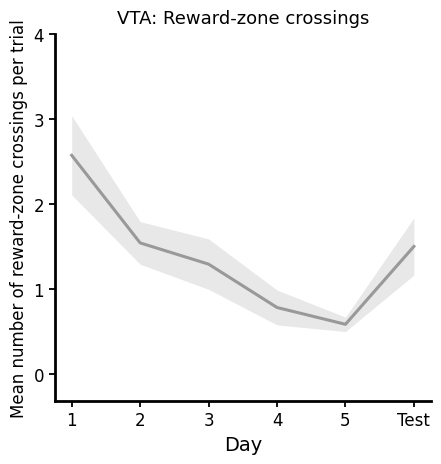

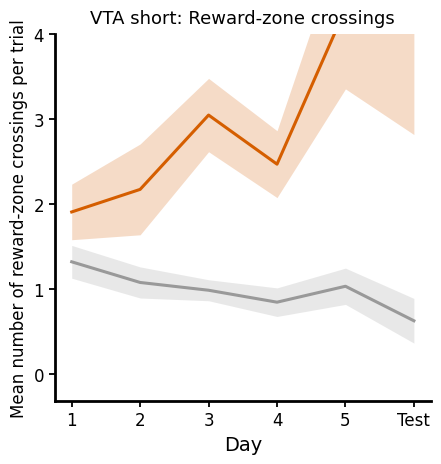

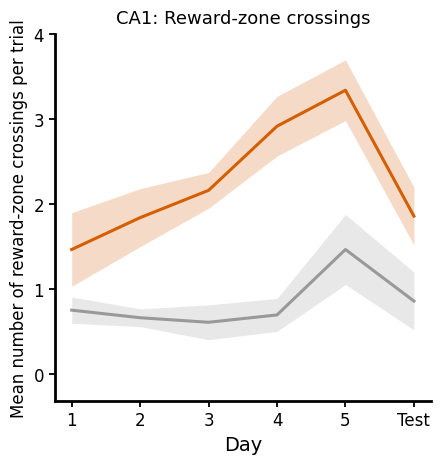

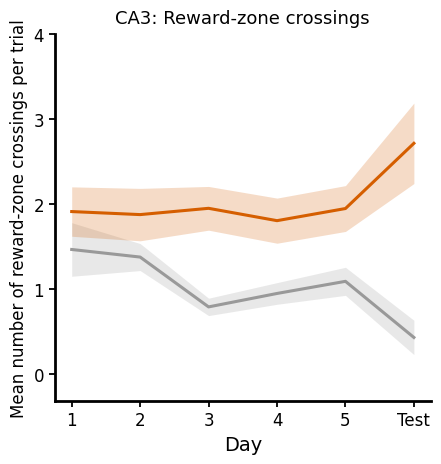

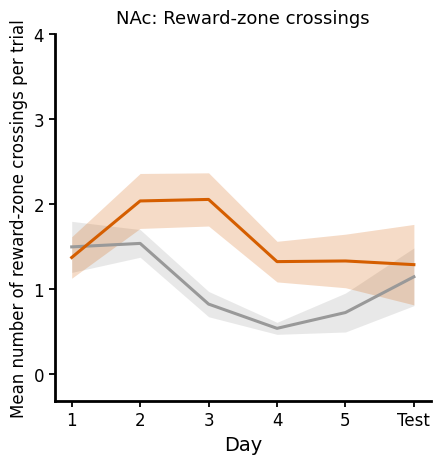

In [ ]:
# ============================================================
# Number of crossings for each reward zone across L1-L5 + Test
# Flexible groups
# Requires meta_cross with:
#   - trigger_id
#   - n_crossings_trig
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ============================================================
# OPTIONS
# ============================================================
GROUPS = ['ChR2', 'ChR2_short', 'CA1', 'CA3', 'NAc']
# GROUPS = ['ChR2', 'eYFP_ChR2', 'NAc']
# GROUPS = ['ChR2', 'NAc', 'NAc_control']
# GROUPS = ['CA1', 'CA3', 'CA1_control']

EXCLUDE_ID = ['AS', 'AN']     # e.g. ['AS', 'AN']
EXCLUDE_SUBS = []             # e.g. [43]

ZONE_IDS = [1, 2]

ZONE_LABELS = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

ZONE_COLORS = {
    1: '#999999',
    2: '#D55E00',
}

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
}

PLOT_MODE = 'separate_figures'   # 'separate_figures' or 'same_figure'

REQUIRE_COMPLETE = False         # True -> only animals with all L1-L5 + Test
PLOT_INDIVIDUAL = False          # True -> faded animal traces
SHOW_SEM_SHADING = True          # False -> no shaded SEM band
SHOW_SEM_ERRORBARS = False       # True -> SEM error bars

# Y-axis options
YMIN = None                      # None -> automatically below 0
YMAX = None                      # e.g. 15, or None for auto
Y_BOTTOM_PAD_FRAC = 0.08         # larger -> 0 further above bottom axis
Y_TICK_STEP = 2                  # integer tick spacing

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ============================================================
# 1. Filter metadata
# ============================================================
mt = meta_cross[
    (meta_cross['genotype'].isin(GROUPS)) &
    (meta_cross['trial_type'].isin(['L', 'T'])) &
    (meta_cross['n_crossings_trig'].notna())
].copy()

if len(EXCLUDE_ID) > 0:
    mt = mt[
        ~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    mt = mt[
        ~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ============================================================
# 2. Assign plot_day: L1-L5 + first post-learning Test = day 6
# ============================================================
mt['plot_day'] = np.nan

mask_L = mt['trial_type'] == 'L'
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep L days 1–5 only
mt = mt[
    (~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

# assign first T session after last L session as day 6, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]

    mt.loc[idx, 'plot_day'] = 6

mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ============================================================
# 3. Helpers
# ============================================================
def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.tick_params(direction='out', length=4, width=1.3)

def apply_y_axis(ax, ymax_candidates=None):
    if YMAX is not None:
        ymax = YMAX
    else:
        if ymax_candidates is None or len(ymax_candidates) == 0:
            ymax = 10
        else:
            ymax = np.nanmax(ymax_candidates)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 10
            else:
                ymax = ymax * 1.25

    if YMIN is not None:
        ymin = YMIN
    else:
        ymin = -Y_BOTTOM_PAD_FRAC * ymax

    ax.set_ylim(ymin, ymax)

    yticks = np.arange(0, int(np.ceil(ymax)) + 1, Y_TICK_STEP)
    if len(yticks) == 0 or yticks[0] != 0:
        yticks = np.insert(yticks, 0, 0)

    ax.set_yticks(yticks)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

def build_zone_matrix_cross(mt_all, genotype, trigger_id):
    perf_mat = []
    subjects = []
    animal_ids = []

    mt_zone = mt_all[
        (mt_all['genotype'] == genotype) &
        (mt_all['trigger_id'] == trigger_id)
    ].copy()

    if mt_zone.empty:
        return None, [], []

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub].copy()

        mean_by_day = ms.groupby('plot_day')['n_crossings_trig'].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_ids.append(str(ms['id'].dropna().iloc[0]))
        else:
            animal_ids.append(str(sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids

# ============================================================
# 4. Build matrices
# ============================================================
zone_data = {}

print("Animals included:")
for g in GROUPS:
    zone_data[g] = {}

    for zid in ZONE_IDS:
        mat, subs, ids = build_zone_matrix_cross(mt, g, zid)

        zone_data[g][zid] = {
            'mat': mat,
            'subs': subs,
            'ids': ids,
        }

        print(f"  {DISPLAY_NAME.get(g, g)} ({g}), {ZONE_LABELS.get(zid, f'Zone {zid}')}:")
        print(f"    n animals plotted = {len(subs)}")
        print(f"    ids = {ids}")

# ============================================================
# 5A. Plot: one figure per genotype, zone 1 vs zone 2
# ============================================================
if PLOT_MODE == 'separate_figures':

    for g in GROUPS:
        fig, ax = plt.subplots(figsize=(5.5, 5))

        ymax_candidates = []

        for zid in ZONE_IDS:
            mat = zone_data[g][zid]['mat']
            subs = zone_data[g][zid]['subs']

            if mat is None or len(subs) == 0:
                continue

            mean_vals = np.nanmean(mat, axis=0)
            sem_vals = sem_by_day(mat)

            col = ZONE_COLORS.get(zid, get_genotype_color(g))
            label = ZONE_LABELS.get(zid, f'Reward zone {zid}')

            if PLOT_INDIVIDUAL:
                for row in mat:
                    ax.plot(
                        x_vals,
                        row,
                        '-',
                        color=col,
                        alpha=0.18,
                        linewidth=1.0,
                        label='_nolegend_',
                        zorder=1
                    )

            if SHOW_SEM_SHADING:
                ax.fill_between(
                    x_vals,
                    mean_vals - sem_vals,
                    mean_vals + sem_vals,
                    color=col,
                    alpha=0.22,
                    linewidth=0,
                    zorder=2
                )

            ax.plot(
                x_vals,
                mean_vals,
                '-',
                color=col,
                linewidth=2.2,
                label=f'{label} (n={len(subs)})',
                zorder=3
            )

            if SHOW_SEM_ERRORBARS:
                ax.errorbar(
                    x_vals,
                    mean_vals,
                    yerr=sem_vals,
                    fmt='none',
                    ecolor=col,
                    elinewidth=1.2,
                    capsize=3,
                    alpha=0.9,
                    zorder=4
                )

            ymax_candidates.append(np.nanmax(mean_vals + sem_vals))

        ax.set_xlabel('Day', fontsize=14)
        ax.set_ylabel('Mean number of reward-zone crossings per trial', fontsize=12)

        ax.set_xticks(np.arange(6))
        ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
        ax.tick_params(axis='y', labelsize=12)

        style_nature(ax)

        ax.set_title(
            f'{DISPLAY_NAME.get(g, g)}: Reward-zone crossings',
            fontsize=13,
            pad=8
        )

        #ax.legend(
         #   loc='center left',
         #   bbox_to_anchor=(1.02, 0.5),
         #   frameon=False,
         #   fontsize=9
        #)

        apply_y_axis(ax, ymax_candidates)

        plt.tight_layout(rect=[0, 0, 0.82, 0.95])
        plt.show()

# ============================================================
# 5B. Plot: all groups/zones on same figure
# ============================================================
elif PLOT_MODE == 'same_figure':

    fig, ax = plt.subplots(figsize=(8, 5.2))

    line_styles = {
        1: '-',
        2: '--',
    }

    ymax_candidates = []

    for g in GROUPS:
        for zid in ZONE_IDS:
            mat = zone_data[g][zid]['mat']
            subs = zone_data[g][zid]['subs']

            if mat is None or len(subs) == 0:
                continue

            mean_vals = np.nanmean(mat, axis=0)
            sem_vals = sem_by_day(mat)

            col = get_genotype_color(g)
            label = (
                f'{DISPLAY_NAME.get(g, g)} '
                f'{ZONE_LABELS.get(zid, f"Zone {zid}")} '
                f'(n={len(subs)})'
            )

            if PLOT_INDIVIDUAL:
                for row in mat:
                    ax.plot(
                        x_vals,
                        row,
                        line_styles.get(zid, '-'),
                        color=col,
                        alpha=0.08,
                        linewidth=0.9,
                        label='_nolegend_',
                        zorder=1
                    )

            if SHOW_SEM_SHADING:
                ax.fill_between(
                    x_vals,
                    mean_vals - sem_vals,
                    mean_vals + sem_vals,
                    color=col,
                    alpha=0.08,
                    linewidth=0,
                    zorder=2
                )

            ax.plot(
                x_vals,
                mean_vals,
                line_styles.get(zid, '-'),
                color=col,
                linewidth=2.1,
                label=label,
                zorder=3
            )

            if SHOW_SEM_ERRORBARS:
                ax.errorbar(
                    x_vals,
                    mean_vals,
                    yerr=sem_vals,
                    fmt='none',
                    ecolor=col,
                    elinewidth=1.0,
                    capsize=3,
                    alpha=0.9,
                    zorder=4
                )

            ymax_candidates.append(np.nanmax(mean_vals + sem_vals))

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel('Mean number of reward-zone crossings per trial', fontsize=12)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    style_nature(ax)

    ax.set_title(
        'Reward-zone crossings',
        fontsize=13,
        pad=8
    )

    ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=8
    )

    apply_y_axis(ax, ymax_candidates)

    plt.tight_layout(rect=[0, 0, 0.80, 0.95])
    plt.show()

else:
    raise ValueError("PLOT_MODE must be 'separate_figures' or 'same_figure'")

Trigger 1: n animals plotted = 7
Trigger 1 animal IDs: ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs: ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs: ['AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
--------------------------------------------------


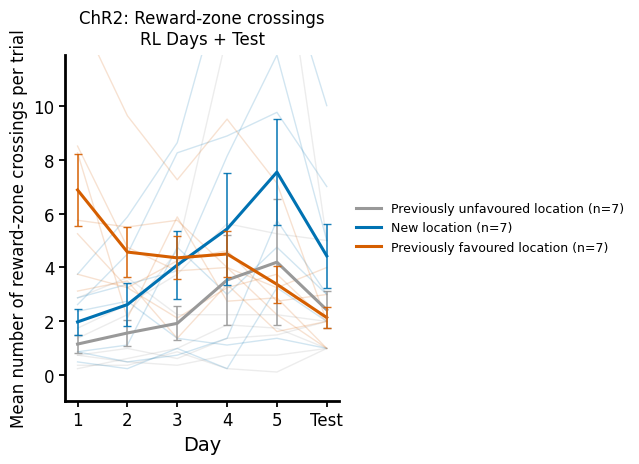

In [20]:
# ============================================================
# ChR2 RL/T: Number of crossings across RL1-RL5 + first T as Test day 6
# Combined plotting code:
#   - default = shaded SEM plot
#   - optional individual faded lines
#   - optional SEM error bars
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# OPTIONS
# ============================================================
GENOTYPE = 'ChR2'

LEARNING_TRIAL_TYPE = 'RL'   # remapping learning
TEST_TRIAL_TYPE = 'T'

TRIGGER_IDS = [1, 2, 3]

REQUIRE_COMPLETE = True      # True = require all RL1-RL5 + Test
PLOT_INDIVIDUAL = True      # True = show faded individual animal lines
SHOW_SEM_SHADING = False      # default shaded plot
SHOW_SEM_ERRORBARS = True   # True = add SEM error bars
SHOW_MARKERS = False         # True = add markers on mean line

FIGSIZE = (8, 5)

YMIN = None                  # None = automatically slightly below 0
YMAX = None                  # e.g. 15, or None for auto
Y_BOTTOM_PAD_FRAC = 0.08     # only used if YMIN is None
Y_TICK_STEP = None           # e.g. 2, or None for matplotlib auto

colors = {
    1: '#999999',  # previously unfavoured
    2: '#0072B2',  # new location
    3: '#D55E00',  # previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ============================================================
# 1. Filter: genotype, RL/T, not short
# ============================================================
mt = meta_cross[
    (meta_cross['short_duration'] != 1) &
    (meta_cross['genotype'] == GENOTYPE) &
    (meta_cross['trial_type'].isin([LEARNING_TRIAL_TYPE, TEST_TRIAL_TYPE])) &
    (meta_cross['n_crossings_trig'].notna())
].copy()

# ============================================================
# 2. Assign plot_day: RL1-RL5 + first post-RL Test = day 6
# ============================================================
mt['plot_day'] = np.nan

mask_learning = mt['trial_type'] == LEARNING_TRIAL_TYPE
mt.loc[mask_learning, 'plot_day'] = mt.loc[mask_learning, 'trial_type_day']

# keep learning days 1–5 only
mt = mt[
    (~mask_learning) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

# assign first T session after last RL session as day 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    learning_ses = ms.loc[ms['trial_type'] == LEARNING_TRIAL_TYPE, 'ses']
    if len(learning_ses) == 0:
        continue

    last_learning_ses = learning_ses.max()

    T_after = ms[
        (ms['trial_type'] == TEST_TRIAL_TYPE) &
        (ms['ses'] > last_learning_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == TEST_TRIAL_TYPE) &
        (mt['ses'] == first_T_ses)
    ]

    mt.loc[idx, 'plot_day'] = 6

mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ============================================================
# 3. Helpers
# ============================================================
def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem

def build_trigger_matrix_cross(mt_all, trigger_id):
    perf_mat = []
    subjects = []
    animal_ids = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id].copy()

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub].copy()

        mean_by_day = ms.groupby('plot_day')['n_crossings_trig'].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_ids.append(str(ms['id'].dropna().iloc[0]))
        else:
            animal_ids.append(str(sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.tick_params(direction='out', length=4, width=1.3)

def apply_y_axis(ax, ymax_candidates):
    if YMAX is not None:
        ymax = YMAX
    else:
        if len(ymax_candidates) == 0:
            ymax = 10
        else:
            ymax = np.nanmax(ymax_candidates)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 10
            else:
                ymax = ymax * 1.25

    if YMIN is not None:
        ymin = YMIN
    else:
        ymin = -Y_BOTTOM_PAD_FRAC * ymax

    ax.set_ylim(ymin, ymax)

    if Y_TICK_STEP is not None:
        yticks = np.arange(0, int(np.ceil(ymax)) + 1, Y_TICK_STEP)
        if len(yticks) == 0 or yticks[0] != 0:
            yticks = np.insert(yticks, 0, 0)
        ax.set_yticks(yticks)

# ============================================================
# 4. Build matrices
# ============================================================
mat_trig = {}
subs_trig = {}
ids_trig = {}

for trig_id in TRIGGER_IDS:
    mat, subs, ids = build_trigger_matrix_cross(mt, trig_id)

    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    ids_trig[trig_id] = ids

    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:", ids)
    print("-" * 50)

all_animals = sorted(set().union(*[set(ids_trig[t]) for t in TRIGGER_IDS]))
n_animals = len(all_animals)

# ============================================================
# 5. Plot
# ============================================================
fig, ax = plt.subplots(figsize=FIGSIZE)

ymax_candidates = []

for trig_id in TRIGGER_IDS:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]

    if mat is None or len(subs) == 0:
        continue

    col = colors[trig_id]

    if PLOT_INDIVIDUAL:
        for row in mat:
            ax.plot(
                x_vals,
                row,
                '-',
                color=col,
                alpha=0.18,
                linewidth=1.0,
                label='_nolegend_',
                zorder=1
            )

    mean_vals = np.nanmean(mat, axis=0)
    sem_vals = sem_by_day(mat)

    if SHOW_SEM_SHADING:
        ax.fill_between(
            x_vals,
            mean_vals - sem_vals,
            mean_vals + sem_vals,
            color=col,
            alpha=0.22,
            linewidth=0,
            zorder=2
        )

    fmt = '-o' if SHOW_MARKERS else '-'

    ax.plot(
        x_vals,
        mean_vals,
        fmt,
        color=col,
        linewidth=2.2,
        markersize=5,
        label=f'{labels[trig_id]} (n={len(subs)})',
        zorder=3
    )

    if SHOW_SEM_ERRORBARS:
        ax.errorbar(
            x_vals,
            mean_vals,
            yerr=sem_vals,
            fmt='none',
            ecolor=col,
            elinewidth=1.2,
            capsize=3,
            alpha=0.9,
            zorder=4
        )

    ymax_candidates.append(np.nanmax(mean_vals + sem_vals))

# ============================================================
# 6. Style
# ============================================================
ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel('Mean number of reward-zone crossings per trial', fontsize=12)

ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.set_title(
    f'{GENOTYPE}: Reward-zone crossings\n'
    f'{LEARNING_TRIAL_TYPE} Days + Test',
    fontsize=12,
    pad=8
)

style_nature(ax)
apply_y_axis(ax, ymax_candidates)

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=9
)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.show()

Animals included per reward zone (RL + Test):
  Reward zone 1: 7 animals
  Reward zone 2: 7 animals
  Reward zone 3: 7 animals

Total unique animals included (any zone): 7
Animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]


/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_61803/1508018613.py:122: RuntimeWarning: Mean of empty slice
  mean_ = np.nanmean(mat, axis=0)
/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


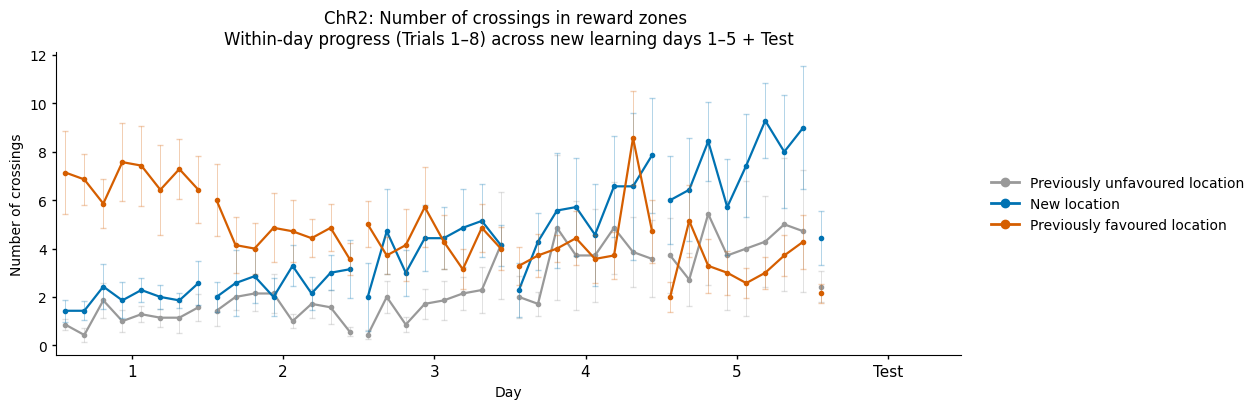

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Trial-by-trial number of crossings in each reward zone
# RL days 1–5 + first T session as Test day 6
# Group: ChR2, using meta_cross (n_crossings_trig)
# Zones: trigger_id 1, 2, 3
# ============================================================

# ----------------------------
# 1) Base filter: RL + T
# ----------------------------
mt = meta_cross[
    (meta_cross['usable'] == 1) &
    (meta_cross['short_duration'] != 1) &
    (meta_cross['genotype'] == 'ChR2') &
    (meta_cross['trial_type'].isin(['RL', 'T'])) &
    (meta_cross['n_crossings_trig'].notna())
].copy()

# ----------------------------
# 2) Assign plot_day:
#    RL → 1–5 (from trial_type_day)
#    T  → 6 (first T session AFTER last RL for each animal)
# ----------------------------
mt['plot_day'] = np.nan

mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 for RL
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))].copy()

# assign Test day (6) per animal using session structure
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

# keep only days 1–6
plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ----------------------------
# 3) Create trial_in_day = 1..8 per session
#    (shared by all trigger zones)
# ----------------------------
if 'trial_id' not in mt.columns:
    mt = mt.reset_index().rename(columns={'index': 'trial_id'})

trial_table = (
    mt[['trial_id', 'sub', 'ses', 'plot_day']]
    .drop_duplicates('trial_id')
    .sort_values(['sub', 'ses', 'plot_day', 'trial_id'])
    .copy()
)

trial_table['trial_in_day'] = trial_table.groupby(['sub', 'ses']).cumcount() + 1
trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)]

mt = mt.merge(
    trial_table[['trial_id', 'trial_in_day']],
    on='trial_id',
    how='inner'
)

# ----------------------------
# 4) Helper: subject × trial matrix for a given plot_day & zone
# ----------------------------
days = plot_days        # [1..6]
trials = np.arange(1, 9)
zone_ids = [1, 2, 3]

def subject_trial_matrix_for_day_and_zone(mt_all, day, zone_id):
    md = mt_all[(mt_all['plot_day'] == day) &
                (mt_all['trigger_id'] == zone_id)]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['n_crossings_trig'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials],
                        dtype=float)
        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ----------------------------
# 5) Plot helper: within-day curves for ONE zone (mean ± SEM)
# ----------------------------
def plot_within_day_curves_for_zone(ax, mt_all, zone_id, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points per day bin

    for day in days:
        mat = subject_trial_matrix_for_day_and_zone(mt_all, day, zone_id)
        if mat is None:
            continue

        x = day + offsets
        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        ax.plot(
            x, mean_,
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            markersize=3
        )
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=min(alpha, 0.3),
            elinewidth=0.7,
            capsize=2
        )

# ----------------------------
# 6) Plot
# ----------------------------
colors = {
    1: '#999999',  # Previously unfavoured
    2: '#0072B2',  # New / current favoured location
    3: '#D55E00',  # Previously favoured
}
labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

for zid in zone_ids:
    plot_within_day_curves_for_zone(
        ax,
        mt,
        zone_id=zid,
        color=colors[zid],
        alpha=1.0
    )

ax.set_xlabel('Day')
ax.set_ylabel('Number of crossings')

# center ticks under each day block
ax.set_xticks(days + 0.5)
ax.set_xticklabels(
    ['1', '2', '3', '4', '5', 'Test'],
    fontsize=11
)

ax.set_xlim(1.0, 6.98)

ax.set_title(
    'ChR2: Number of crossings in reward zones \n'
    'Within-day progress (Trials 1–8) across new learning days 1–5 + Test',
    fontsize=12
)

# journal / NN style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=3, width=1)
ax.grid(False)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=colors[1], lw=2, marker='o', label=labels[1]),
    Line2D([0], [0], color=colors[2], lw=2, marker='o', label=labels[2]),
    Line2D([0], [0], color=colors[3], lw=2, marker='o', label=labels[3]),
]

plt.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# animal counts per zone (for info)
subs_zone = {
    zid: sorted(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())
    for zid in zone_ids
}
print("Animals included per reward zone (RL + Test):")
for zid in zone_ids:
    print(f"  Reward zone {zid}: {len(subs_zone[zid])} animals")

all_animals = sorted(set().union(*subs_zone.values()))
print(f"\nTotal unique animals included (any zone): {len(all_animals)}")
print("Animal IDs:", all_animals)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

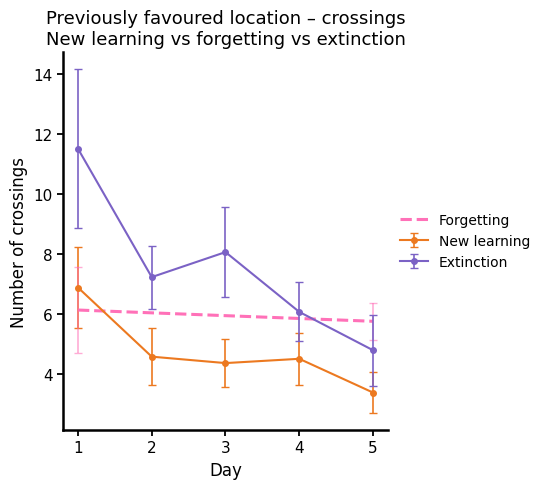

In [23]:
# plot number of crossings in previously favoured location for new learning vs forgetting/extinction


# ============================================================
# 1) RL stage – number of crossings into previously favoured location (trigger 3)
# ============================================================

# RL/T filter from meta_cross
mt_rl_cross = meta_cross[
    (meta_cross['usable'] == 1) &
    (meta_cross['short_duration'] != 1) &
    (meta_cross['genotype'] == 'ChR2') &
    (meta_cross['trial_type'].isin(['RL', 'T']))
].copy()

# Assign plot_day: RL days = 1–5, Test (T) = 6
mt_rl_cross['plot_day'] = np.nan

mask_RL = (mt_rl_cross['trial_type'] == 'RL')
mt_rl_cross.loc[mask_RL, 'plot_day'] = mt_rl_cross.loc[mask_RL, 'trial_type_day']

# keep only RL 1–5 for RL
mt_rl_cross = mt_rl_cross[(~mask_RL) | (mt_rl_cross['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# Keep the same T=6 assignment logic (for consistency, though not used directly)
for sub in mt_rl_cross['sub'].unique():
    ms = mt_rl_cross[mt_rl_cross['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue
    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue
    first_T_ses = T_after['ses'].min()
    idx = mt_rl_cross.index[
        (mt_rl_cross['sub'] == sub) &
        (mt_rl_cross['trial_type'] == 'T') &
        (mt_rl_cross['ses'] == first_T_ses)
    ]
    mt_rl_cross.loc[idx, 'plot_day'] = 6

# We only care about RL days 1–5 here
rl_days = np.arange(1, 6)

def rl_fav_cross_stats(mt_rl_cross, trigger_id=3):
    """
    Number of crossings into 'previously favoured' trigger (id=3)
    for RL days 1–5, averaged:
      1) per subject per day
      2) across subjects
    Returns mean_n, sem_n (arrays of length 5).
    """
    df = mt_rl_cross[
        (mt_rl_cross['trigger_id'] == trigger_id) &
        (mt_rl_cross['trial_type'] == 'RL') &
        (mt_rl_cross['plot_day'].isin(rl_days)) &
        (mt_rl_cross['n_crossings_trig'].notna())
    ].copy()

    mean_n = np.full(len(rl_days), np.nan)
    sem_n  = np.full(len(rl_days), np.nan)

    for i, d in enumerate(rl_days):
        df_day = df[df['plot_day'] == d]
        if df_day.empty:
            continue

        # average per animal first, then across animals
        per_sub = (
            df_day.groupby('sub')['n_crossings_trig']
                  .mean()
        )
        vals = per_sub.values.astype(float)
        if vals.size == 0:
            continue

        mean_n[i] = np.nanmean(vals)
        if vals.size > 1:
            sem_n[i] = np.nanstd(vals, ddof=1) / np.sqrt(vals.size)

    return mean_n, sem_n  # units: crossings (counts)

mean_rl_cross, sem_rl_cross = rl_fav_cross_stats(mt_rl_cross, trigger_id=3)


# ============================================================
# 2) Forgetting / extinction – number of crossings into favoured zone (trigger 2)
# ============================================================

# Filter: ChR2, TEST, usable, not short, forgetting/extinction
meta_T_cross = meta_cross[
    (meta_cross['usable'] == 1) &
    (meta_cross['trial_type'] == 'T') &
    (meta_cross['genotype'] == 'ChR2') &
    (meta_cross['short_duration'] != 1) &
    (meta_cross['test_type'].isin(['forgetting', 'extinction'])) &
    (meta_cross['n_crossings_trig'].notna())
].copy()

test_days = np.arange(1, 6)  # test days 1–5

def build_cross_zone2(meta_df):
    """
    For meta_df subset (forgetting or extinction),
    compute number of crossings into trigger_id = 2 per test day (1–5):

      1) mean crossings per subject per day
      2) mean & SEM across subjects

    Returns mean_n, sem_n (each length 5, in counts).
    """
    df = meta_df[meta_df['trigger_id'] == 2].copy()
    mean_n = np.full(len(test_days), np.nan)
    sem_n  = np.full(len(test_days), np.nan)

    for i, d in enumerate(test_days):
        df_day = df[df['trial_type_day'] == d]
        if df_day.empty:
            continue

        per_sub = (
            df_day.groupby('sub')['n_crossings_trig']
                  .mean()
        )
        vals = per_sub.values.astype(float)
        if vals.size == 0:
            continue

        mean_n[i] = np.nanmean(vals)
        if vals.size > 1:
            sem_n[i] = np.nanstd(vals, ddof=1) / np.sqrt(vals.size)

    return mean_n, sem_n  # crossings


meta_forg_cross = meta_T_cross[meta_T_cross['test_type'] == 'forgetting'].copy()
meta_ext_cross  = meta_T_cross[meta_T_cross['test_type'] == 'extinction'].copy()

mean_forg_cross, sem_forg_cross = build_cross_zone2(meta_forg_cross)
mean_ext_cross,  sem_ext_cross  = build_cross_zone2(meta_ext_cross)


# ============================================================
# 3) Combined plot: RL + forgetting/extinction – favoured zone (number of crossings)
# ============================================================

plt.figure(figsize=(7, 5))

# ---- RL previously favoured location (solid, orange) ----
plt.errorbar(
    rl_days, mean_rl_cross, yerr=sem_rl_cross,
    fmt='-o',
    color="#EC7920",         # same RL orange as before
    ecolor="#EC7920",
    elinewidth=1.2,
    capsize=3,
    markersize=4,
    label='New learning'
)

# ---- colours for test trials (same style as your other plots) ----
col_f = '#FF69B4'    # pink for forgetting
col_e = '#7b62c5ff'  # purple for extinction

# ---- Forgetting (only day 1 & 5, dashed) ----
forget_days = np.array([1, 5])
x_f = forget_days
y_f = np.array([mean_forg_cross[0], mean_forg_cross[4]])
e_f = np.array([sem_forg_cross[0],  sem_forg_cross[4]])

plt.plot(
    x_f, y_f,
    '--',
    color=col_f,
    linewidth=2.2,
    alpha=0.95,
    label='Forgetting'
)
plt.errorbar(
    x_f, y_f, yerr=e_f,
    fmt='none',
    ecolor=col_f,
    alpha=0.55,
    capsize=3,
    elinewidth=1.2
)

# ---- Extinction (day 1–5, solid) ----
plt.errorbar(
    test_days, mean_ext_cross, yerr=sem_ext_cross,
    fmt='-o',
    color=col_e,
    ecolor=col_e,
    elinewidth=1.2,
    capsize=3,
    markersize=4,
    label='Extinction'
)

# ---- Axes, style ----
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.3)

plt.xlabel('Day', fontsize=12)
plt.ylabel('Number of crossings', fontsize=12)
plt.xticks(rl_days, [str(d) for d in rl_days], fontsize=11)
plt.yticks(fontsize=11)

plt.title(
    'Previously favoured location – crossings\n'
    'New learning vs forgetting vs extinction',
    fontsize=13,
    pad=6
)

plt.legend(
    frameon=False,
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

N per group (Day 5, crossings):
  New Learning (RL day 5, trig3): 7
  Forgetting (Test day 5, trig2): 8
  Extinction (Test day 5, trig2): 7
RL vs Forg: raw p = 0.0124
RL vs Ext: raw p = 0.201
Forg vs Ext: raw p = 0.288

FDR-corrected p-values (Benjamini–Hochberg):
  RL vs Forg: p_FDR = 0.0373
  RL vs Ext: p_FDR = 0.288
  Forg vs Ext: p_FDR = 0.288


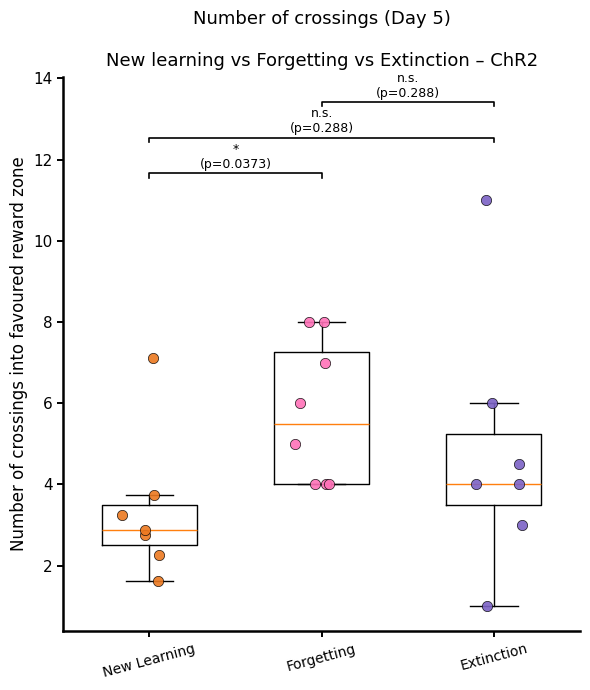

In [29]:
# boxplot number of crossings in previously favoured location for new learning vs forgetting/extinction
from scipy.stats import mannwhitneyu

# Try to import statsmodels for FDR correction
try:
    from statsmodels.stats.multitest import multipletests
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("Warning: statsmodels not installed → FDR correction skipped (raw p-values used).")

# ------------------------------------------------------------
# 1) Extract data for the three groups (all ChR2)
#    - New Learning: RL day 5, trigger_id = 3  (previously favoured)
#    - Forgetting:   Test day 5, trigger_id = 2
#    - Extinction:   Test day 5, trigger_id = 2
#    Using number of crossings per animal (mean across trials)
#    Source: meta_cross with column 'n_crossings_trig'
# ------------------------------------------------------------

# ---- New Learning (RL day 5, trig=3) ----
rl_df = meta_cross[
    (meta_cross['usable'] == 1) &
    (meta_cross['short_duration'] != 1) &
    (meta_cross['genotype'] == 'ChR2') &
    (meta_cross['trial_type'] == 'RL') &
    (meta_cross['trigger_id'] == 3) &
    (meta_cross['trial_type_day'] == 5) &
    (meta_cross['n_crossings_trig'].notna())
].copy()

rl_per_sub = (
    rl_df.groupby('sub')['n_crossings_trig']
         .mean()
         .astype(float)
)
vals_rl = rl_per_sub.values   # counts


# ---- Forgetting (Test day 5, T, trig=2) ----
forg_df = meta_cross[
    (meta_cross['usable'] == 1) &
    (meta_cross['short_duration'] != 1) &
    (meta_cross['genotype'] == 'ChR2') &
    (meta_cross['trial_type'] == 'T') &
    (meta_cross['test_type'] == 'forgetting') &
    (meta_cross['trigger_id'] == 2) &
    (meta_cross['trial_type_day'] == 5) &
    (meta_cross['n_crossings_trig'].notna())
].copy()

forg_per_sub = (
    forg_df.groupby('sub')['n_crossings_trig']
           .mean()
           .astype(float)
)
vals_forg = forg_per_sub.values   # counts


# ---- Extinction (Test day 5, T, trig=2) ----
ext_df = meta_cross[
    (meta_cross['usable'] == 1) &
    (meta_cross['short_duration'] != 1) &
    (meta_cross['genotype'] == 'ChR2') &
    (meta_cross['trial_type'] == 'T') &
    (meta_cross['test_type'] == 'extinction') &
    (meta_cross['trigger_id'] == 2) &
    (meta_cross['trial_type_day'] == 5) &
    (meta_cross['n_crossings_trig'].notna())
].copy()

ext_per_sub = (
    ext_df.groupby('sub')['n_crossings_trig']
          .mean()
          .astype(float)
)
vals_ext = ext_per_sub.values   # counts

print("N per group (Day 5, crossings):")
print("  New Learning (RL day 5, trig3):", len(vals_rl))
print("  Forgetting (Test day 5, trig2):", len(vals_forg))
print("  Extinction (Test day 5, trig2):", len(vals_ext))

# ------------------------------------------------------------
# 2) Prepare boxplot data
# ------------------------------------------------------------
groups = ["New Learning", "Forgetting", "Extinction"]
data   = [vals_rl,       vals_forg,     vals_ext]
positions = np.arange(len(groups))

colors = {
    "New Learning": "#EC7920",   # orange (same as your line plot)
    "Forgetting":   "#FF72B8",   # pink
    "Extinction":   "#7b62c5ff"  # purple
}

# ------------------------------------------------------------
# 3) Boxplot + jittered individual points
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 7))

# plain black boxes, no fliers
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.55,
    patch_artist=False,
    showfliers=False
)

# jittered animal points
for i, g in enumerate(groups):
    vals = data[i]
    if len(vals) == 0:
        continue
    jitter = 0.10
    x = np.random.normal(positions[i], jitter, size=len(vals))
    ax.scatter(
        x, vals,
        s=55,
        color=colors[g],
        edgecolor='k',
        linewidth=0.5,
        alpha=0.9,
        zorder=3
    )

# ------------------------------------------------------------
# 4) Mann–Whitney tests + FDR + significance stars
# ------------------------------------------------------------
def mannwhitney_safe(a, b):
    if (len(a) < 1) or (len(b) < 1):
        return np.nan
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    return p

p_raw = []

comparisons = [
    ("RL vs Forg",   0, 1, vals_rl,   vals_forg),
    ("RL vs Ext",    0, 2, vals_rl,   vals_ext),
    ("Forg vs Ext",  1, 2, vals_forg, vals_ext)
]

for name, i1, i2, v1, v2 in comparisons:
    p = mannwhitney_safe(v1, v2)
    p_raw.append(p)
    print(f"{name}: raw p = {p:.3g}" if not np.isnan(p) else f"{name}: p = NaN")

p_raw = np.array(p_raw, dtype=float)

# FDR correction (if statsmodels available)
if HAS_SM:
    mask_valid = ~np.isnan(p_raw)
    p_adj = p_raw.copy()
    if mask_valid.any():
        rej, p_corr, _, _ = multipletests(p_raw[mask_valid], alpha=0.05, method='fdr_bh')
        p_adj[mask_valid] = p_corr
    print("\nFDR-corrected p-values (Benjamini–Hochberg):")
    for (name, *_), p_corr_val in zip(comparisons, p_adj):
        print(f"  {name}: p_FDR = {p_corr_val:.3g}")
else:
    p_adj = p_raw
    print("\nUsing raw p-values for annotation (no FDR correction).")

def p_to_stars(p):
    if np.isnan(p):   return "n.s."
    if p < 1e-4:      return "****"
    if p < 1e-3:      return "***"
    if p < 1e-2:      return "**"
    if p < 0.05:      return "*"
    return "n.s."

# Add significance bars above boxes
all_vals = np.concatenate([v for v in data if len(v) > 0])
y_max = np.nanmax(all_vals)
y_step = 0.08 * y_max  # vertical spacing
current_y = y_max * 1.05

for (name, x1, x2, _, _), p in zip(comparisons, p_adj):
    stars = p_to_stars(p)
    if np.isnan(p):
        continue

    # bar
    ax.plot(
        [x1, x1, x2, x2],
        [current_y, current_y + 0.01 * y_max,
         current_y + 0.01 * y_max, current_y],
        color='k',
        linewidth=1.2
    )
    # text (stars + p)
    ax.text(
        (x1 + x2) / 2,
        current_y + 0.015 * y_max,
        f"{stars}\n(p={p:.3g})",
        ha='center',
        va='bottom',
        fontsize=9
    )

    current_y += y_step

# ------------------------------------------------------------
# 5) Axes, labels, style
# ------------------------------------------------------------
ax.set_xticks(positions)
ax.set_xticklabels(groups, rotation=15)
ax.set_ylabel('Number of crossings into favoured reward zone', fontsize=12)
ax.set_xlabel('')
ax.set_title(
    'Number of crossings (Day 5)\n \n'
    'New learning vs Forgetting vs Extinction – ChR2',
    fontsize=13,
    pad=8
)

# Nature-ish style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.4)
plt.yticks(fontsize=11)
plt.xticks(fontsize=10)

plt.tight_layout()
plt.show()